# Query layer demo (Phase 5 Week 8)

Partial retrieval from the consolidated `scale_run.duckdb` via `wdn_pipeline.query.DatasetQuery`. Research consumers slice specific nodes, time windows and scenario classes without downloading the whole dataset. Every cell runs top to bottom against whatever scenarios the scale run produced (selections are resolved from the catalogue, not hard-coded).

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt

from wdn_pipeline.query import DatasetQuery

DB = next(p for p in [Path('outputs/scale_run.duckdb'), Path('../outputs/scale_run.duckdb')] if p.exists())
q = DatasetQuery(DB)

cat = q.scenarios()
print(f'scenarios: {len(cat)}')
print('\nby type:')
print(cat['scenario_type'].value_counts())
print('\nby network:')
print(cat['network_name'].value_counts())
cat.head()

scenarios: 505

by type:
scenario_type
leak            200
sensor_fault    160
normal           85
cumulative       60
Name: count, dtype: int64

by network:
network_name
fowm     130
hanoi    130
net3     130
jilin    115
Name: count, dtype: int64


,scenario_basename,config_path,scenario_type,scenario_label,network_name,seed,demand_model,duration_seconds,num_leaks,num_sensor_faults,num_interactions,validation_severity,fault_summary_json,inserted_at
0,fowm_cumulative_0_602716314,configs/scale/fowm_cumulative_0.yaml,cumulative,cumulative_0,fowm,602716314,PDD,86400,1,1,0,warning,"{""interactions"": [], ""leaks"": [{""area_m2"": 0.0...",2026-06-10 00:33:44.359805
1,fowm_cumulative_10_1929640923,configs/scale/fowm_cumulative_10.yaml,cumulative,cumulative_10,fowm,1929640923,PDD,86400,1,1,0,ok,"{""interactions"": [], ""leaks"": [{""area_m2"": 0.0...",2026-06-10 00:33:46.144938
2,fowm_cumulative_11_1227389104,configs/scale/fowm_cumulative_11.yaml,cumulative,cumulative_11,fowm,1227389104,PDD,86400,1,1,0,ok,"{""interactions"": [], ""leaks"": [{""area_m2"": 0.0...",2026-06-10 00:33:45.583036
3,fowm_cumulative_12_1743564768,configs/scale/fowm_cumulative_12.yaml,cumulative,cumulative_12,fowm,1743564768,PDD,86400,1,1,0,warning,"{""interactions"": [], ""leaks"": [{""area_m2"": 0.0...",2026-06-10 00:33:48.310348
4,fowm_cumulative_13_283004605,configs/scale/fowm_cumulative_13.yaml,cumulative,cumulative_13,fowm,283004605,PDD,86400,1,1,0,warning,"{""interactions"": [], ""leaks"": [{""area_m2"": 0.0...",2026-06-10 00:33:46.798037


## 1. Pressure for three nodes over a 6h window from one leak scenario

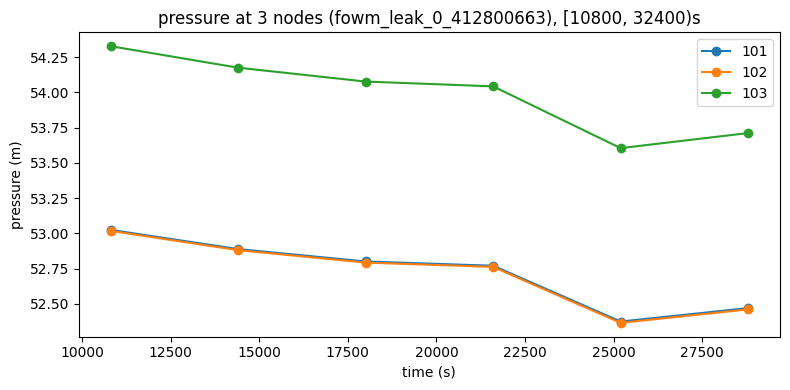

,101,102,103
time_seconds,,,
10800,53.025494,53.018398,54.328408
14400,52.889333,52.881712,54.175874
18000,52.801453,52.793492,54.077426
21600,52.771077,52.762999,54.043396
25200,52.375374,52.365939,53.605413
28800,52.470759,52.461689,53.712155


In [2]:
leaks = q.scenarios(scenario_type='leak')
scenario = leaks['scenario_basename'].iloc[0]
network = leaks['network_name'].iloc[0]

# Resolve three real node names from the data for this scenario.
nodes = list(
    q.sql(
        'SELECT DISTINCT name FROM pressure_long WHERE scenario_basename = ? ORDER BY name LIMIT 3',
        [scenario],
    )['name']
)
t0, t1 = 3 * 3600, 9 * 3600  # a 6 hour window
wide = q.pressure(scenario=scenario, nodes=nodes, t_start=t0, t_end=t1, wide=True)

ax = wide.plot(marker='o', figsize=(8, 4))
ax.set_title(f'pressure at 3 nodes ({scenario}), [{t0}, {t1})s')
ax.set_xlabel('time (s)')
ax.set_ylabel('pressure (m)')
plt.tight_layout()
plt.show()
wide

## 2. The same node across every leak scenario on one network (single query)

50 leak scenarios on fowm, node 101: 1250 rows in one query


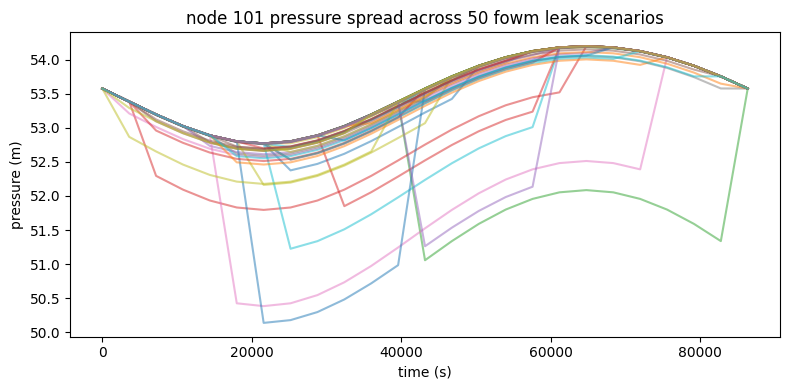

In [3]:
net_leaks = list(q.scenarios(scenario_type='leak', network=network)['scenario_basename'])
node = nodes[0]
df = q.pressure(scenarios=net_leaks, nodes=[node])
print(f'{len(net_leaks)} leak scenarios on {network}, node {node}: {len(df)} rows in one query')

fig, ax = plt.subplots(figsize=(8, 4))
for scen, grp in df.groupby('scenario_basename'):
    ax.plot(grp['time_seconds'], grp['value'], alpha=0.5)
ax.set_title(f'node {node} pressure spread across {len(net_leaks)} {network} leak scenarios')
ax.set_xlabel('time (s)')
ax.set_ylabel('pressure (m)')
plt.tight_layout()
plt.show()

## 3. Only the anomalous timesteps for one scenario

In [4]:
anomalous = q.labels(scenario=scenario, label=1)
allrows = q.labels(scenario=scenario)
print(f'{scenario}: {len(anomalous)} / {len(allrows)} timesteps are anomalous')
anomalous.head()

fowm_leak_0_412800663: 7 / 25 timesteps are anomalous


,scenario_basename,time_seconds,label
0,fowm_leak_0_412800663,25200,1
1,fowm_leak_0_412800663,28800,1
2,fowm_leak_0_412800663,32400,1
3,fowm_leak_0_412800663,36000,1
4,fowm_leak_0_412800663,39600,1


## 4. The partial-retrieval argument: one queryable file vs the flat-file tree

The consolidated DuckDB is built long-only (`--duckdb-long-only`, decision D35): the long tables plus the `scenarios` catalogue, no per-scenario wide tables. It is one indexed file you can slice in milliseconds with a single query. The flat CSV tree is smaller on disk but you would have to download and parse the whole tree (thousands of files) to pull one node's series.

In [5]:
def _tree_bytes(root: Path, pattern: str) -> int:
    return sum(p.stat().st_size for p in root.rglob(pattern))

scale_dir = next((p for p in [Path('outputs/scale'), Path('../outputs/scale')] if p.exists()), None)
db_mb = DB.stat().st_size / 1e6
print(f'DuckDB file: {db_mb:.1f} MB')
if scale_dir is not None:
    csv_mb = _tree_bytes(scale_dir, '*.csv') / 1e6
    parquet_mb = _tree_bytes(scale_dir, '*.parquet') / 1e6
    print(f'equivalent CSV tree:     {csv_mb:.1f} MB across {sum(1 for _ in scale_dir.rglob("*.csv"))} files')
    print(f'equivalent Parquet tree: {parquet_mb:.1f} MB')

# Time a typical slice query: one node over a 6h window from one scenario.
start = time.perf_counter()
_ = q.pressure(scenario=scenario, nodes=[node], t_start=t0, t_end=t1)
elapsed_ms = (time.perf_counter() - start) * 1000
print(f'\nslice query latency: {elapsed_ms:.1f} ms')

DuckDB file: 205.5 MB


equivalent CSV tree:     67.4 MB across 3030 files
equivalent Parquet tree: 77.8 MB

slice query latency: 3.0 ms


## 5. The same slice from the shell (CLI equivalent)

In [6]:
import subprocess
import sys

out_csv = Path('query_demo_slice.csv')
cmd = [
    sys.executable, '-m', 'wdn_pipeline.runner', 'query', str(DB),
    '--quantity', 'pressure', '--scenario', scenario,
    '--nodes', ','.join(nodes), '--t-start', str(t0), '--t-end', str(t1),
    '--out', str(out_csv),
]
print('$ ' + ' '.join(cmd[2:]))
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout.strip())
print('wrote', out_csv, '=', out_csv.stat().st_size, 'bytes')
out_csv.unlink()
q.close()

$ wdn_pipeline.runner query ../outputs/scale_run.duckdb --quantity pressure --scenario fowm_leak_0_412800663 --nodes 101,102,103 --t-start 10800 --t-end 32400 --out query_demo_slice.csv


wrote 18 rows to query_demo_slice.csv
wrote query_demo_slice.csv = 947 bytes
